In [1]:
import sys
from pathlib import Path

# Add src to path for imports
project_root = Path.cwd().parent.parent
src_path = project_root / 'src'
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

import neural_additive_models.data_utils as data_utils
import neural_additive_models.graph_builder as graph_builder

from utils import load_col_min_max, inverse_min_max_scaler

Instructions for updating:
non-resource variables are not supported in the long term


In [ ]:
dataset_name = 'Recidivism'
is_regression = False
data =  data_utils.load_dataset(dataset_name)
data_x, data_y, column_names = data
col_min_max = load_col_min_max(dataset_name)

In [ ]:
from utils import create_fold_indices

NUM_FOLDS = 5
fold_train_indices, fold_test_indices = create_fold_indices(
    data_x,
    data_y,
    num_folds=NUM_FOLDS,
    is_regression=is_regression,
    random_state=42
)

print(f"Fold test set sizes: {[len(idx) for idx in fold_test_indices]}")
print(f"Total test samples: {sum(len(idx) for idx in fold_test_indices)}")
print(f"Total dataset size: {len(data_x)}")
print(f"Test set percentage: {100*sum(len(idx) for idx in fold_test_indices)/len(data_x):.1f}%")


Fold test set sizes: [1235, 1235, 1234, 1234, 1234]
Total test samples: 6172
Total dataset size: 6172
Test set percentage: 100.0%


In [5]:
from utils import prepare_feature_arrays, get_dataset_config

# Step 1: Prepare data
SINGLE_FEATURES_ORIGINAL, UNIQUE_FEATURES_ORIGINAL, UNIQUE_FEATURES = prepare_feature_arrays(
    data_x, column_names, col_min_max, inverse_min_max_scaler
)

# Step 2: Load dataset-specific config
COL_NAMES, FEATURE_LABEL_MAPPING, CATEGORICAL_NAMES = get_dataset_config(dataset_name, column_names)


In [ ]:
from utils import gather_nam_predictions_and_hist_data

# Set results directory
project_root = Path.cwd().parent.parent
base_logdir = project_root / 'results' / 'training' / 'nam' / 'compas'

all_preds_per_fold, all_hist_data, all_mean_pred = gather_nam_predictions_and_hist_data(
    fold_test_indices=fold_test_indices,
    data_x=data_x,
    column_names=column_names,
    unique_features=UNIQUE_FEATURES,
    dataset_name=dataset_name,
    base_logdir=str(base_logdir),
    num_folds=5,
    num_splits=20,
    print_every=5
)


Processing fold 1 (test set size: 1235)...
Using checkpoint: ./compas/fold_1/split_1/model_0/best_checkpoint\model.ckpt-280
Feature widths: [64, 4, 12, 4, 64, 64]
Num input features: 6
INFO:tensorflow:Restoring parameters from ./compas/fold_1/split_1/model_0/best_checkpoint\model.ckpt-280
✅ Restored NAM from checkpoint.
Using checkpoint: ./compas/fold_1/split_2/model_0/best_checkpoint\model.ckpt-680
Feature widths: [64, 4, 12, 4, 64, 64]
Num input features: 6
INFO:tensorflow:Restoring parameters from ./compas/fold_1/split_2/model_0/best_checkpoint\model.ckpt-680
✅ Restored NAM from checkpoint.
Using checkpoint: ./compas/fold_1/split_3/model_0/best_checkpoint\model.ckpt-360
Feature widths: [64, 4, 12, 4, 64, 64]
Num input features: 6
INFO:tensorflow:Restoring parameters from ./compas/fold_1/split_3/model_0/best_checkpoint\model.ckpt-360
✅ Restored NAM from checkpoint.
Using checkpoint: ./compas/fold_1/split_4/model_0/best_checkpoint\model.ckpt-120
Feature widths: [64, 4, 12, 4, 64, 64]


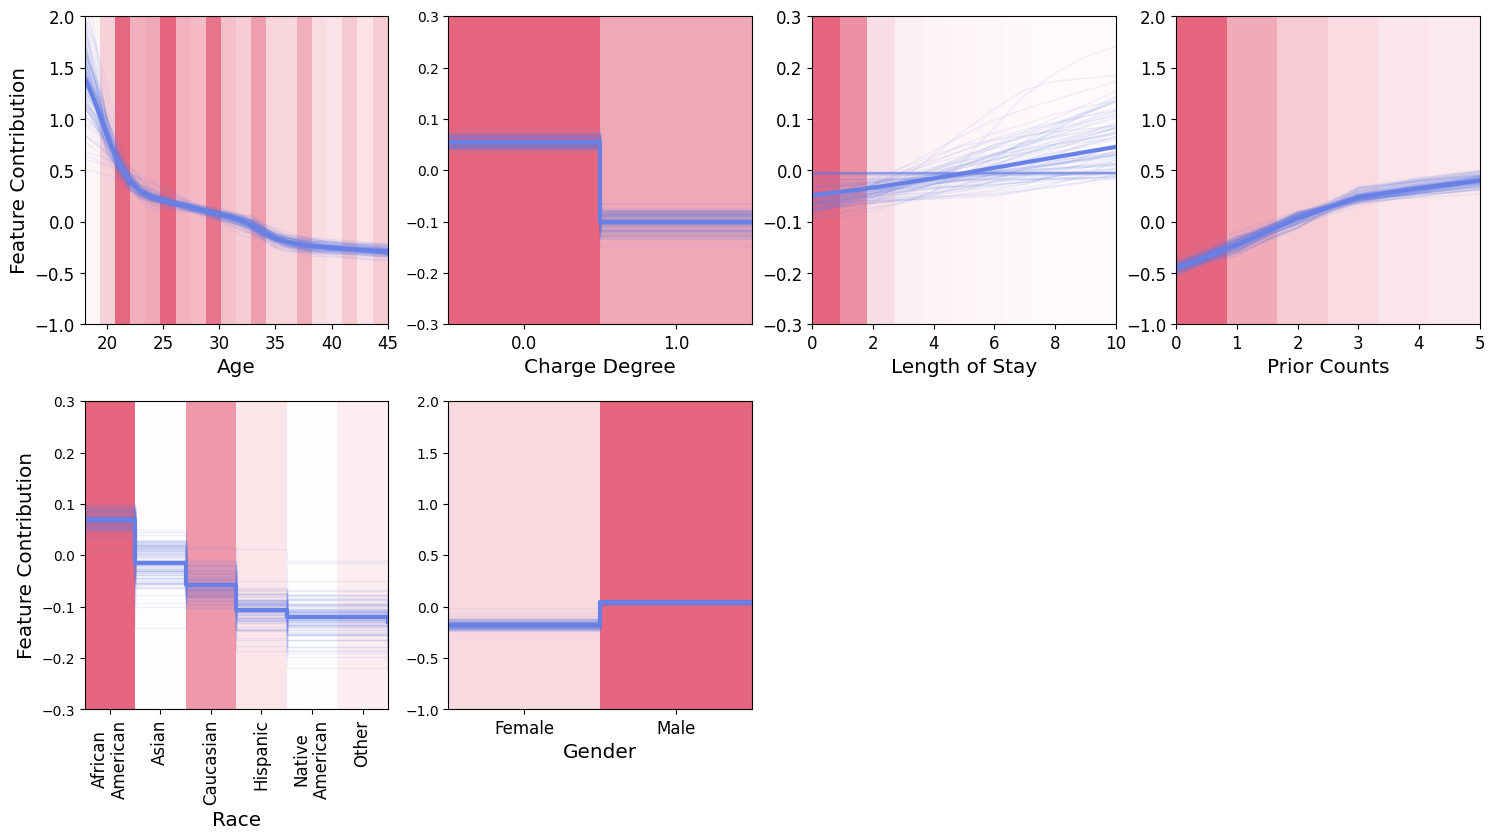

In [7]:
from utils import plot_nam_contributions_with_density

x_limits = {
    'age': 45,
    'length_of_stay': 10,
    'priors_count': 5
}

y_limits = {
    'age': (-1, 2),
    'c_charge_degree': (-0.3, 0.3),
    'length_of_stay': (-0.3, 0.3),
    'priors_count': (-1, 2),
    'race': (-0.3, 0.3),
    'sex': (-1, 2)
}

fig = plot_nam_contributions_with_density(
    hist_data=all_hist_data,
    unique_features=UNIQUE_FEATURES_ORIGINAL,
    single_features=SINGLE_FEATURES_ORIGINAL,
    categorical_names=CATEGORICAL_NAMES,
    col_mapping=COL_NAMES[dataset_name],
    feature_mapping=FEATURE_LABEL_MAPPING[dataset_name],
    mean_pred=all_mean_pred,
    feature_to_use=column_names,
    x_limits=x_limits,
    y_limits=y_limits
)


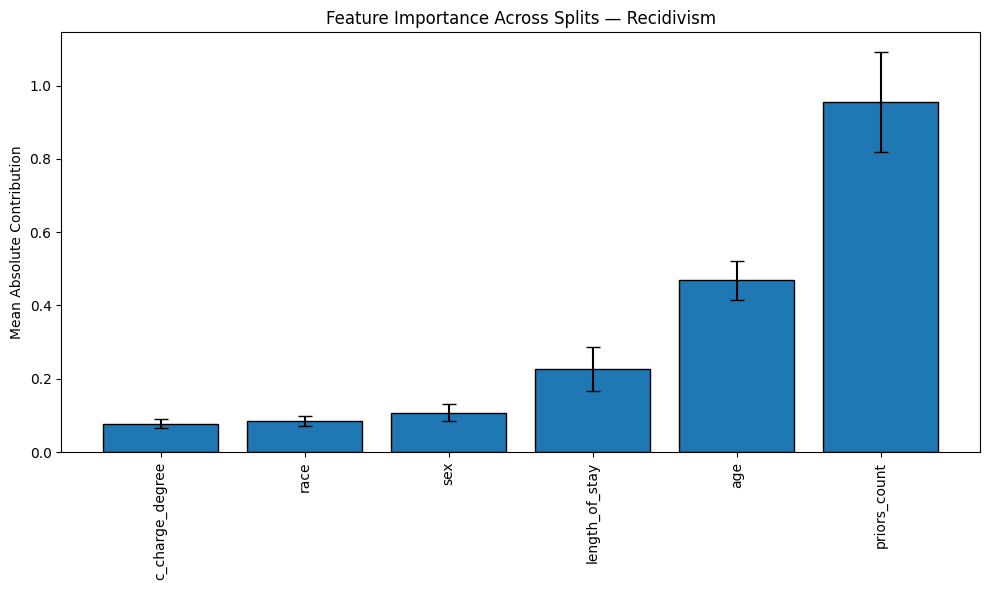

In [ ]:
from utils import plot_feature_importance_across_splits

sorted_features, sorted_mean, sorted_std = plot_feature_importance_across_splits(
    all_hist_data,
    all_mean_pred,
    dataset_name
)


In [ ]:
from utils import evaluate_ensemble_across_folds

fold_aucs, avg_auc, std_auc = evaluate_ensemble_across_folds(
    all_preds_per_fold,
    fold_test_indices,
    data_y,
    is_regression=False,
    verbose=True
)


Fold 1 AUC (test set only): 0.7470 (n=1235)
Fold 2 AUC (test set only): 0.7426 (n=1235)
Fold 3 AUC (test set only): 0.7537 (n=1234)
Fold 4 AUC (test set only): 0.7242 (n=1234)
Fold 5 AUC (test set only): 0.7362 (n=1234)

Average Ensemble AUC across folds (test sets only): 0.7407
Std of Ensemble AUC across folds: 0.0100
